# Исследование рынка заведений общественного питания Москвы

- Автор: Мелания Ланская
- Дата: 30.06.2026

### Цели и задачи проекта

В данном проекте используются данные о заведениях общественного питания Москвы, составленные на основе сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года. Цель работы - провести исследовательский анализ рынка и сформировать рекомендации для инвесторов фонда «Shut Up and Take My Money», которые планируют открыть заведение общественного питания в Москве.

### Описание данных

Для анализа предоставлены два датасета.

Датасет `rest_info.csv` содержит информацию о заведениях общественного питания:
- `name` — название заведения
- `address` — адрес заведения
- `district` — административный округ
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»
- `hours` — информация о днях и часах работы
- `rating` — рейтинг заведения по оценкам пользователей Яндекс Карт (высшая оценка - 5.0)
- `chain` — признак сетевого заведения: 1 - сетевое, 0 - несетевое
- `seats` — количество посадочных мест

Датасет `rest_price.csv` содержит информацию о ценах:
- `price` — категория цен, например «средние», «выше среднего»
- `avg_bill` — средняя стоимость заказа в виде текстового диапазона
- `middle_avg_bill` — медиана среднего чека (заполняется только для записей «Средний счёт»)
- `middle_coffee_cup` — медиана цены капучино (заполняется только для записей «Цена одной чашки капучино»)

### Содержимое проекта

Исследование будет выполнено в несколько этапов:
1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговый вывод и рекомендации.

---

## 1. Загрузка данных и знакомство с ними

На первом этапе исследования необходимо загрузить данные и ознакомиться с их структурой. Для этого загрузим необходимые библиотеки и данные из двух датасетов: `rest_info.csv` и `rest_price.csv`.

In [1]:
!pip install phik==0.11.0 -q

In [2]:
# Импортируем библиотеку pandas
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные о заведениях в датафрейм rest_info
rest_info = pd.read_csv('/datasets/rest_info.csv')

# Выгружаем данные о ценах в датафрейм rest_price
rest_price = pd.read_csv('/datasets/rest_price.csv')

Для начала выведем первые строки каждого датафрейма с помощью метода `head()`, чтобы познакомиться со структурой данных. Затем воспользуемся методом `info()`, который позволит оценить типы данных, количество заполненных значений и обнаружить возможные проблемы, требующие обработки на этапе предобработки.

In [4]:
# Выводим первые строки датафрейма rest_info
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме rest_info
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания Москвы.

Изучим типы данных и их корректность:

- **Строковые данные (`object`).** Столбцы `id`, `name`, `category`, `address` и `district` содержат текстовую информацию - тип `object` для них корректен. Столбец `hours` также имеет тип `object` и хранит текстовое описание режима работы. На его основе в дальнейшем будет создан бинарный признак `is_24_7`.

- **Числовые данные.** Столбец `rating` имеет тип `float64` - корректно, поскольку оценки могут быть дробными. Столбец `chain` имеет тип `int64` и принимает значения 0 или 1, что соответствует описанию. Столбец `seats` должен содержать целочисленные значения, однако хранится как `float64` - вероятнее всего, из-за наличия пропущенных значений.

По результатам метода `info()` обнаружены пропущенные значения в двух столбцах:
- `hours` - 536 пропусков (8406 - 7870)
- `seats` - 3611 пропусков (8406 - 4795)

Причины возникновения пропусков и способы их обработки будут рассмотрены на этапе предобработки данных.

Теперь познакомимся с данными датасета `rest_price.csv`.

In [6]:
# Выводим первые строки датафрейма rest_price
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме rest_price
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк с информацией о 
ценовых категориях заведений.

Рассмотрим типы данных второго датафрейма и оценим их соответствие содержимому столбцов:

- Столбец `id` содержит уникальный идентификатор заведения и будет использован для объединения двух датасетов.
- Столбец `price` имеет тип `object` - текстовые категории цен. Содержит 743 пропуска (4058 - 3315), причины которых предстоит изучить.
- Столбец `avg_bill` имеет тип `object` и хранит текстовое описание стоимости заказа. Содержит 242 пропуска (4058 - 3816).
- Столбцы `middle_avg_bill` и `middle_coffee_cup` имеют тип `float64`. Большое количество пропусков в них ожидаемо: согласно описанию данных, эти столбцы заполняются только для определённых категорий записей в столбце `avg_bill`.

Важное наблюдение: датасет `rest_price.csv` содержит **4058 строк**, тогда как `rest_info.csv` - **8406 строк**. Это означает, что данные о ценах представлены не для всех заведений. Следовательно, объединение датасетов необходимо выполнить с помощью метода `merge()` по столбцу `id`.

---

### Промежуточный вывод

Первичное знакомство с данными показало следующее:

- Датасет `rest_info.csv` содержит 8406 строк и 9 столбцов с информацией о заведениях общественного питания, датасет `rest_price.csv` - 4058 строк и 5 столбцов с данными о ценах.
- Пропущенные значения обнаружены в столбцах `hours` и `seats` датасета `rest_info`, а также в столбцах `price` и `avg_bill` датасета `rest_price` - все они потребуют отдельного анализа на этапе предобработки.
- Столбец `seats` хранится как `float64` из-за наличия пропусков, хотя по смыслу должен быть целочисленным.
- Датасеты содержат разное количество строк, поэтому их объединение будет выполнено методом `merge()` по столбцу `id`.
- Столбец `hours` потребует отдельной обработки для создания признака `is_24_7`.

### Подготовка единого датафрейма

Для дальнейшей работы объединим данные двух датасетов в один датафрейм. Поскольку данные о ценах представлены не для всех заведений, важно сохранить все строки из основного датасета `rest_info`. Объединим датафреймы методом `merge()` по столбцу `id`, используя тип объединения `left`. С полученным датафреймом `df` продолжим работу на всех последующих этапах.

In [8]:
# Объединяем датафреймы по столбцу id с сохранением всех заведений из rest_info
df = rest_info.merge(rest_price, on='id', how='left')
print('Количество строк до объединения:', rest_info.shape[0])
print('Количество строк после объединения:', df.shape[0])
print('Количество уникальных id:', df['id'].nunique())

Количество строк до объединения: 8406
Количество строк после объединения: 8406
Количество уникальных id: 8406


Количество строк после объединения не изменилось, что подтверждает корректность выполнения объединения и сохранение всех заведений из основного датафрейма. Для части заведений данные о ценах отсутствуют, что ожидаемо из-за меньшего объёма датасета rest_price.

In [9]:
# Выводим информацию об объединённом датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [10]:
# Выводим первые строки объединённого датафрейма
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


Данные двух датасетов успешно объединены в единый датафрейм `df`, который 
содержит 13 столбцов и 8406 строк. Все заведения из `rest_info` сохранились - 
для части из них данные о ценах отсутствуют и представлены пропусками, что 
ожидаемо с учётом разного объёма исходных датасетов.

## 2. Предобработка данных

На предыдущем этапе мы познакомились с данными и объединили два датасета в единый датафрейм. Теперь необходимо подготовить данные к исследовательскому анализу: проверить корректность типов данных, изучить и обработать пропущенные значения, проверить наличие дубликатов, а также создать новые столбцы для дальнейшей работы.

### 2.1. Типы данных

Начнём с проверки типов данных в объединённом датафрейме. На этапе знакомства с данными было выявлено, что столбец `seats` имеет тип `float64`, хотя по смыслу должен содержать целые числа. Причиной является наличие пропущенных значений - в pandas целочисленный тип не поддерживает `NaN`. Обработаем этот столбец после работы с пропусками. Остальные типы данных соответствуют содержимому столбцов.

Также проверим столбец `chain` - он принимает значения 0 и 1 и является бинарным признаком. При необходимости его можно будет оптимизировать.

In [11]:
# Проверяем типы данных в объединённом датафрейме
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

### 2.2. Пропущенные значения

Рассчитаем количество и долю пропущенных значений в каждом столбце датафрейма.

In [12]:
# Подсчитываем количество и долю пропущенных значений в каждом столбце
missing_values = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
})

missing_values.query('missing_count > 0').sort_values(
    by='missing_percent',
    ascending=False
)

,missing_count,missing_percent
middle_coffee_cup,7871,93.64
middle_avg_bill,5257,62.54
price,5091,60.56
avg_bill,4590,54.60
seats,3611,42.96
hours,536,6.38


По результатам проверки обнаружены пропущенные значения в следующих столбцах:

- **`hours`** - 536 пропусков (окло 6%). Информация о режиме работы могла отсутствовать в источнике данных или не была добавлена владельцем заведения. Заменим пропуски на строку `'данные отсутствуют'`, чтобы сохранить строки для дальнейшего анализа. При создании признака `is_24_7` такие заведения получат значение `False`.

- **`seats`** - 3611 пропусков (43%). Можно предположить, что часть заведений не указала количество посадочных мест в источнике данных. Удаление таких строк привело бы к существенной потере наблюдений, поэтому пропуски оставлены без замены.

- **`price`** - 5091 пропуск (около 61%), **`avg_bill`** - 4590 пропусков (почти 55%), **`middle_avg_bill`** - 5257 пропусков (63%), **`middle_coffee_cup`** - 7871 пропуск (94%). Большинство пропусков в этих столбцах объясняется двумя причинами: во-первых, для части заведений данные о ценах отсутствовали в датасете `rest_price` (4348 заведений не имели соответствия при объединении); во-вторых, столбцы `middle_avg_bill` и `middle_coffee_cup` по условию заполняются только для определённых категорий записей в `avg_bill`. Оставим эти пропуски как есть - они отражают реальную неполноту исходных данных.

In [13]:
# Заменяем пропуски в столбце hours на строку 'данные отсутствуют'
df['hours'] = df['hours'].fillna('данные отсутствуют')

In [14]:
# Проверяем результат замены пропусков в столбце hours
df['hours'].isna().sum()

0

### 2.3. Явные и неявные дубликаты

Проверим данные на наличие полных дубликатов строк, а также неявных дубликатов по сочетанию названия и адреса заведения - такая пара значений должна быть уникальной для каждого заведения. Перед проверкой нормализуем текстовые столбцы: приведём значения к нижнему регистру и уберём лишние пробелы.

In [15]:
# Проверяем наличие полных дубликатов
df.duplicated().sum()

0

In [16]:
# Нормализуем столбцы name и address: приводим к нижнему регистру и убираем пробелы
df['name'] = df['name'].str.lower().str.strip()
df['address'] = df['address'].str.lower().str.strip()

# Проверяем неявные дубликаты по сочетанию названия и адреса
df.duplicated(subset=['name', 'address']).sum()

4

In [17]:
# Удаляем неявные дубликаты по сочетанию названия и адреса
df = df.drop_duplicates(subset=['name', 'address'])

# Проверяем размер датафрейма после удаления дубликатов
df.shape

(8402, 13)

После нормализации текстовых столбцов `name` и `address` было обнаружено 4 неявных дубликата по сочетанию названия и адреса заведения. Все они были удалены - в датафрейме осталось 8402 строки. Потеря составила менее 0.05% данных, что является несущественной долей.

### 2.4. Создание столбца `is_24_7`

Для дальнейшего анализа создадим столбец `is_24_7`, который будет указывать, работает ли заведение ежедневно и круглосуточно. Рассмотрим уникальные значения столбца `hours`, чтобы определить, как в данных обозначается круглосуточный режим работы.

In [18]:
# Изучаем уникальные значения в столбце hours
df['hours'].unique()

array(['ежедневно, 10:00–22:00',
       'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
       'ежедневно, 09:00–22:00', ...,
       'пн-пт 08:30–21:30; сб,вс 09:00–21:30',
       'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00',
       'пн-сб 10:30–21:30'], dtype=object)

Вывод показал большое количество уникальных значений в столбце `hours` - форматы записи режима работы существенно различаются. Проанализируем отдельно значения, содержащие подстроку `'ежедневно'`, а затем `'круглосуточно'`.

In [19]:
# Выводим значения, содержащие подстроку 'ежедневно'
df[df['hours'].str.contains('ежедневно', na=False)]['hours'].unique()

array(['ежедневно, 10:00–22:00', 'ежедневно, 09:00–22:00',
       'ежедневно, 10:00–23:00', 'ежедневно, 12:00–00:00',
       'ежедневно, круглосуточно', 'ежедневно, 10:00–21:00',
       'ежедневно, 08:00–22:00', 'ежедневно, 13:00–00:00',
       'ежедневно, 09:00–21:00', 'ежедневно, 10:00–19:00',
       'ежедневно, 08:00–21:00', 'ежедневно, 09:00–23:00',
       'ежедневно, 08:00–23:00', 'ежедневно, 11:00–00:00',
       'ежедневно, 09:00–02:00', 'ежедневно, 12:00–23:00',
       'ежедневно, 12:00–03:00', 'ежедневно, 16:00–06:00',
       'ежедневно, 09:00–01:00', 'ежедневно, 11:00–23:00',
       'ежедневно, 09:00–06:00', 'ежедневно, 10:00–21:30',
       'ежедневно, 08:00–00:00', 'ежедневно, 06:00–20:00',
       'ежедневно, 10:00–20:00', 'ежедневно, 11:00–22:00',
       'ежедневно, 10:30–23:00', 'ежедневно, 07:00–00:00',
       'ежедневно, 10:00–22:00, перерыв 16:00–16:20',
       'ежедневно, 13:00–04:00', 'ежедневно, 11:00–19:00',
       'ежедневно, 16:00–04:00', 'ежедневно, 09:00–00:00',


In [20]:
# Выводим значения, содержащие подстроку 'круглосуточно'
df[df['hours'].str.contains('круглосуточно', na=False)]['hours'].unique()

array(['ежедневно, круглосуточно',
       'пн 00:01–12:00, перерыв 12:00–13:30; вт-чт 13:30–12:00; пт 13:30–00:00; сб,вс круглосуточно',
       'вт-вс круглосуточно', 'сб круглосуточно', 'пт-вс круглосуточно',
       'пн,ср,чт,пт,сб,вс круглосуточно',
       'пн 10:00–00:00; вт-сб круглосуточно; вс 00:00–23:00',
       'пн-чт 07:30–23:00; пт 07:30–00:00; сб круглосуточно; вс 00:00–23:00',
       'пн круглосуточно; вт-чт 12:00–00:00; пт 12:00–02:00; сб 11:00–02:00; вс 14:00–00:00',
       'пн-чт 08:00–23:00; пт,сб круглосуточно; вс 08:00–23:00',
       'пн-ср 07:00–23:00; чт 07:00–00:00; пт,сб круглосуточно; вс 00:00–23:00',
       'пн-чт 08:00–23:00; пт 08:00–00:00; сб круглосуточно; вс 00:00–23:00',
       'пн 08:00–23:00; вт-пт 08:00–00:00; сб круглосуточно; вс 00:00–23:00',
       'пн-ср 09:00–00:00; чт-вс круглосуточно',
       'пн-чт круглосуточно; пт 00:00–05:00, перерыв 05:00–07:00; сб 07:00–05:00; вс 07:00–00:00',
       'пн-чт 11:00–23:00; пт 11:00–00:00; сб круглосуточно; вс 

Анализ значений столбца `hours` показал, что слово «круглосуточно» встречается в самых разных контекстах: для отдельных дней недели (`'сб круглосуточно'`, `'пт-вс круглосуточно'`), для части недели (`'вт-вс круглосуточно'`, `'пн-чт круглосуточно'`) и только в одном случае - для всей недели (`'ежедневно, круглосуточно'`). Таким образом, для корректного определения признака `is_24_7` недостаточно просто проверить наличие подстроки «круглосуточно» - необходимо точное совпадение со значением `'ежедневно, круглосуточно'`.

In [21]:
# Создаём столбец is_24_7: True - только если заведение работает ежедневно и круглосуточно
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

Проверим распределение полученного признака.

In [22]:
# Проверяем распределение значений в столбце is_24_7
is_24_7_distribution = pd.DataFrame({
    'count': df['is_24_7'].value_counts(),
    'percent': df['is_24_7'].value_counts(normalize=True).mul(100).round(1)
})

is_24_7_distribution

,count,percent
False,7672,91.3
True,730,8.7


---

### Промежуточный вывод

Предобработка показала, что данные в целом пригодны для исследовательского анализа. Критических несоответствий в типах данных не выявлено: столбец `seats` остался в формате `float64`, поскольку содержит пропуски, а это стандартное поведение pandas.

Основные особенности данных связаны с пропущенными значениями. Пропуски в `hours` составляют около 6%, поэтому они были заменены на значение `данные отсутствуют`. Пропуски в `seats` составляют почти 43%, а в ценовых столбцах - от 55% до 94%. Удаление таких строк привело бы к значительной потере данных, поэтому эти пропуски были сохранены.

Также были нормализованы текстовые столбцы `name` и `address`, после чего обнаружено и удалено 4 неявных дубликата. Потеря составила менее 0.05% данных. Дополнительно создан признак `is_24_7`: 730 заведений, или 8.7%, работают ежедневно и круглосуточно.

После предобработки итоговый датафрейм содержит 8402 строки и 14 столбцов. Данные готовы к исследовательскому анализу.

## 3. Исследовательский анализ данных

На этом этапе проведём исследовательский анализ данных и ответим на вопросы, которые помогут инвесторам принять решение об открытии заведения в Москве. Для каждого шага анализа будем использовать подходящие визуализации.

---

### Задача 1. Категории заведений

Проанализируем распределение заведений по категориям и определим, какие форматы представлены на рынке чаще всего.

In [23]:
# Подсчитываем количество заведений по каждой категории
category_counts = df['category'].value_counts()
category_counts

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [24]:
# Подсчитываем долю заведений каждой категории
(df['category'].value_counts() / len(df) * 100).round(1)

кафе               28.3
ресторан           24.3
кофейня            16.8
бар,паб             9.1
пиццерия            7.5
быстрое питание     7.2
столовая            3.7
булочная            3.0
Name: category, dtype: float64

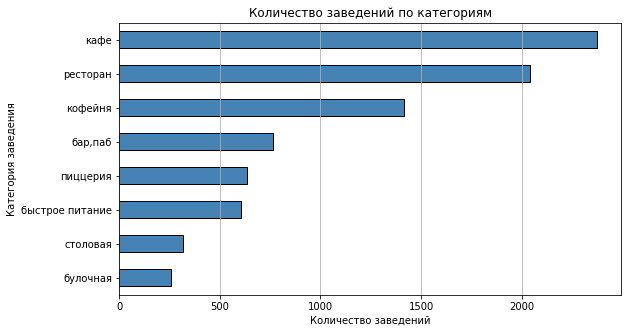

In [25]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(9, 5))
category_counts.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)

plt.title('Количество заведений по категориям')
plt.xlabel('Количество заведений')
plt.ylabel('Категория заведения')
plt.grid(axis='x')
plt.show()

Анализ категорий показал, что рынок общественного питания Москвы сконцентрирован вокруг нескольких массовых форматов. Наиболее распространены кафе - 2376 заведений, рестораны - 2042 и кофейни - 1413. Вместе эти три категории составляют почти 70% всех объектов.

Менее представлены бары и пабы, пиццерии и заведения быстрого питания. Наименьшая доля приходится на столовые и булочные - около 4% и 3% соответственно.

Такое распределение показывает, что основная конкуренция сосредоточена в универсальных форматах — кафе, ресторанах и кофейнях. Более узкие форматы занимают меньшую долю рынка, но могут быть интересны как менее насыщенные ниши.

---

### Задача 2. Распределение заведений по административным округам

Проанализируем распределение заведений по административным округам Москвы и отдельно рассмотрим категории заведений, представленные в Центральном административном округе.

In [26]:
# Подсчитываем количество заведений по административным округам
district_counts = df['district'].value_counts()
district_counts

Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

In [27]:
# Подсчитываем долю заведений по округам
(district_counts / len(df) * 100).round(1)

Центральный административный округ         26.7
Северный административный округ            10.7
Южный административный округ               10.6
Северо-Восточный административный округ    10.6
Западный административный округ            10.1
Восточный административный округ            9.5
Юго-Восточный административный округ        8.5
Юго-Западный административный округ         8.4
Северо-Западный административный округ      4.9
Name: district, dtype: float64

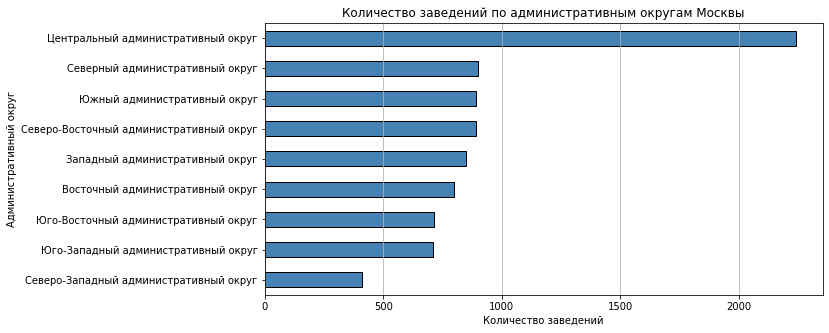

In [28]:
# Строим горизонтальную столбчатую диаграмму распределения заведений по округам
plt.figure(figsize=(10, 5))

district_counts.sort_values().plot(
    kind='barh',
    legend=False,
    color='steelblue',
    edgecolor='black'
)

plt.title('Количество заведений по административным округам Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Административный округ')
plt.grid(axis='x')
plt.show()

Дополнительно рассмотрим структуру заведений в Центральном административном округе. Этот округ лидирует по количеству объектов, поэтому важно понять, какие категории заведений формируют его насыщенность.

In [29]:
# Отбираем заведения Центрального административного округа
central_district = df[df['district'] == 'Центральный административный округ']

# Подсчитываем количество заведений каждой категории в Центральном административном округе
central_category_counts = central_district['category'].value_counts()
central_category_counts

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

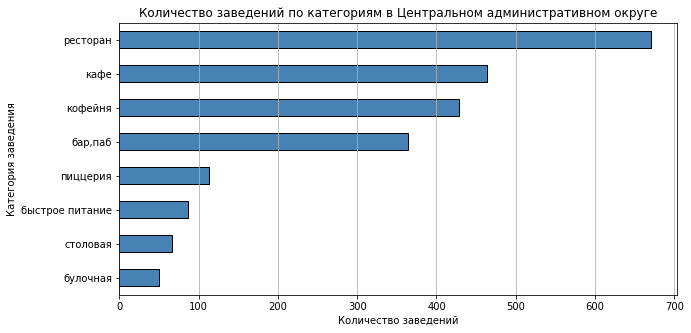

In [30]:
# Строим график распределения заведений по категориям в Центральном административном округе
plt.figure(figsize=(10, 5))

central_category_counts.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)

plt.title('Количество заведений по категориям в Центральном административном округе')
plt.xlabel('Количество заведений')
plt.ylabel('Категория заведения')
plt.grid(axis='x')
plt.show()

Распределение заведений по округам оказалось неравномерным. Центральный административный округ значительно опережает остальные: здесь сосредоточено 2242 заведения, или около 27% всех объектов. Это делает центр Москвы главным районом концентрации заведений общественного питания.

Большинство остальных округов представлены близкими значениями - примерно от 8% до 11%. Наименьшее количество заведений находится в Северо-Западном административном округе - 409 объектов, то есть менее 5% от общего числа.

Высокая концентрация заведений в центре может быть связана с деловым и туристическим трафиком, большим количеством офисов, культурных объектов и высокой проходимостью. При этом высокая плотность заведений также означает более сильную конкуренцию.

Дополнительный анализ Центрального административного округа показал, что его насыщенность формируется прежде всего ресторанами (670 заведений), кафе (464) и кофейнями (428). Значительную долю также занимают бары и пабы (364). Остальные категории представлены заметно меньшим количеством объектов: пиццерии - 113, заведения быстрого питания - 87, столовые - 66 и булочные - 50.

Таким образом, Центральный административный округ не только является лидером по общему количеству заведений, но и сохраняет структуру рынка, в которой преобладают наиболее массовые и востребованные форматы - рестораны, кафе и кофейни. Именно они формируют основную часть инфраструктуры общественного питания в центре Москвы и ориентированы как на жителей города, так и на высокий туристический и деловой трафик.

---

### Задача 3. Сетевые и несетевые заведения

Изучим соотношение сетевых и несетевых заведений в данных. Сначала рассмотрим общую структуру рынка, а затем оценим долю сетевых заведений в каждой категории.

Столбец `chain` является бинарным признаком: значение `1` обозначает сетевое заведение, а значение `0` - несетевое. Для общего распределения посчитаем количество заведений каждого типа.

In [31]:
# Подсчитываем количество сетевых и несетевых заведений
chain_counts = df['chain'].value_counts().sort_index()

# Заменяем числовые значения на понятные подписи
chain_counts.index = ['несетевые', 'сетевые']
chain_counts

несетевые    5199
сетевые      3203
Name: chain, dtype: int64

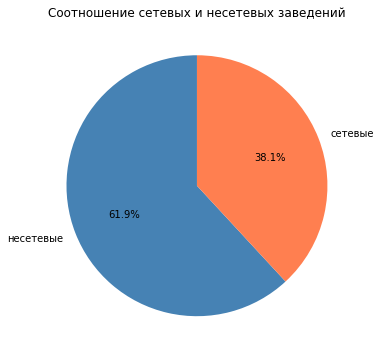

In [32]:
# Строим круговую диаграмму соотношения сетевых и несетевых заведений
plt.figure(figsize=(6, 6))

chain_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['steelblue', 'coral'],
    startangle=90
)

plt.title('Соотношение сетевых и несетевых заведений')
plt.ylabel('')
plt.show()

По общему распределению видно, что в Москве преобладают несетевые заведения. Это ожидаемо для рынка общественного питания: открыть одно самостоятельное заведение проще, чем развивать сеть с несколькими точками. Однако общий график не показывает, в каких категориях сетевой формат распространён сильнее, поэтому дополнительно рассмотрим долю сетевых заведений внутри каждой категории.

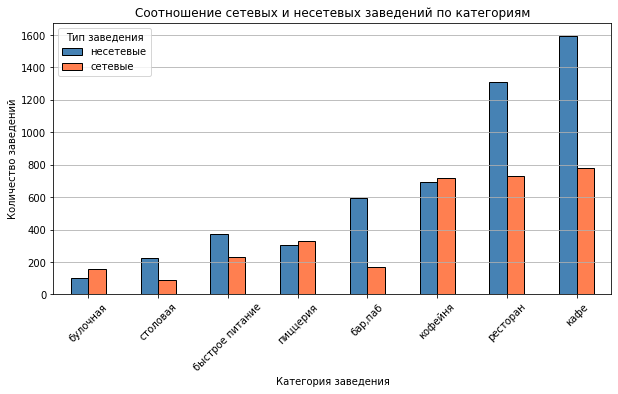

In [33]:
# Таблица для графика
chain_category = (
    df.groupby('category')['chain']
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={0: 'несетевые', 1: 'сетевые'})
)

# Добавляем итог и сортируем категории
chain_category['total'] = chain_category['несетевые'] + chain_category['сетевые']
chain_category = chain_category.sort_values('total')

# Строим график без служебного столбца total
chain_category[['несетевые', 'сетевые']].plot(
    kind='bar',
    figsize=(10, 5),
    rot=45,
    color=['steelblue', 'coral'],
    edgecolor='black'
)

plt.title('Соотношение сетевых и несетевых заведений по категориям')
plt.xlabel('Категория заведения')
plt.ylabel('Количество заведений')
plt.legend(title='Тип заведения')
plt.grid(axis='y')
plt.show()

График показывает, что во всех категориях количество несетевых заведений превышает количество сетевых. Особенно заметна эта разница среди кафе и ресторанов: эти категории представлены на рынке больше всего, но при этом в них преобладают самостоятельные заведения.

Сетевые заведения также встречаются во всех категориях, однако их количество значительно ниже. Для более точного сравнения категорий важно дополнительно рассмотреть не только абсолютное количество сетевых заведений, но и их долю внутри каждой категории.

In [34]:
# Рассчитываем количество заведений и долю сетевых заведений по категориям
chain_by_category = (
    df.groupby('category')
    .agg(
        places_count=('id', 'count'),
        chain_count=('chain', 'sum'),
        chain_percent=('chain', 'mean')
    )
    .sort_values('chain_percent', ascending=False)
)

# Переводим долю сетевых заведений в проценты
chain_by_category['chain_percent'] = (chain_by_category['chain_percent'] * 100).round(1)
chain_by_category

,places_count,chain_count,chain_percent
category,,,
булочная,256,157,61.3
пиццерия,633,330,52.1
кофейня,1413,720,51.0
быстрое питание,603,232,38.5
ресторан,2042,729,35.7
кафе,2376,779,32.8
столовая,315,88,27.9
"бар,паб",764,168,22.0


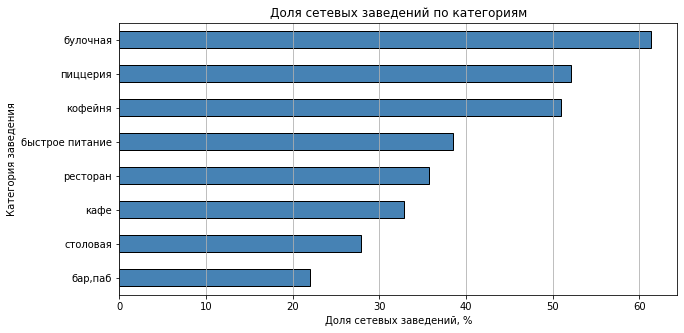

In [35]:
# Строим график доли сетевых заведений по категориям
plt.figure(figsize=(10, 5))

chain_by_category['chain_percent'].sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)

plt.title('Доля сетевых заведений по категориям')
plt.xlabel('Доля сетевых заведений, %')
plt.ylabel('Категория заведения')
plt.grid(axis='x')
plt.show()

Анализ показал, что рынок общественного питания Москвы в большей степени представлен несетевыми заведениями: их доля составляет 61.9%, тогда как сетевые заведения занимают 38.1%.

В разрезе категорий сетевой формат распространён неравномерно. Самая высокая доля сетевых заведений наблюдается у булочных - 61.3%, пиццерий - 52.1% и кофеен - 51%. Эти форматы проще стандартизировать и масштабировать: в них легче повторять меню, технологию приготовления, интерьер и модель обслуживания.

Наименее выражен сетевой формат у баров и пабов - 22%, столовых - 27.9%, кафе - 32.8% и ресторанов - 35.7%. Для этих категорий большую роль могут играть индивидуальная концепция, атмосфера, локация и авторское меню.

Таким образом, в целом рынок остаётся преимущественно несетевым, однако булочные, пиццерии и кофейни демонстрируют высокий потенциал для сетевого развития.

---

### Задача 4. Количество посадочных мест

Проанализируем распределение количества посадочных мест. Это позволит определить наличие выбросов и выяснить, какое количество посадочных мест является наиболее типичным для различных категорий заведений.

In [36]:
# Изучаем статистические показатели столбца seats
df['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

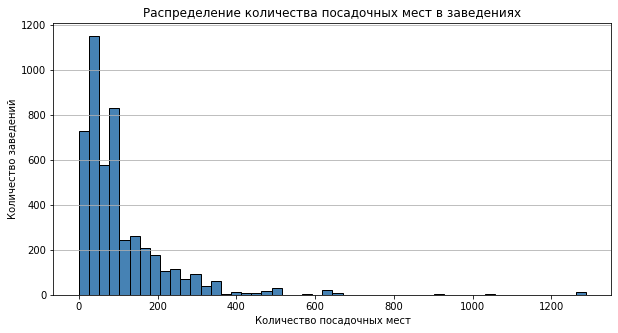

In [37]:
# Строим гистограмму распределения количества посадочных мест
plt.figure(figsize=(10, 5))

df['seats'].dropna().plot(
    kind='hist',
    bins=50,
    color='steelblue',
    edgecolor='black'
)

plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Количество заведений')
plt.grid(axis='y')
plt.show()

Большинство заведений рассчитано на небольшое количество посетителей. При этом распределение имеет длинный правый хвост, что может свидетельствовать о наличии заведений с очень большим количеством посадочных мест. Для более детального изучения выбросов построим диаграмму размаха.

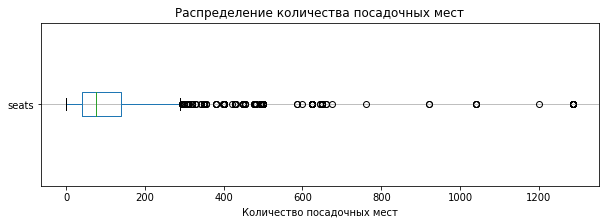

In [38]:
# Строим диаграмму размаха для проверки выбросов
plt.figure(figsize=(10, 3))

df.boxplot(column='seats', vert=False)

plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.grid(axis='x')
plt.show()

Диаграмма размаха подтверждает наличие выбросов. В данных присутствуют заведения с существенно большим количеством посадочных мест по сравнению с большинством остальных объектов.

Подобные значения не обязательно являются ошибками. Они могут соответствовать крупным ресторанам, банкетным залам, столовым, фуд-кортам или другим заведениям, рассчитанным на большое количество посетителей. Поскольку такие значения выглядят реалистичными, исключать их из анализа не будем.

In [39]:
# Определяем медианное количество посадочных мест по каждой категории
seats_by_category = df.groupby('category')['seats'].median().sort_values(ascending=False)
seats_by_category

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

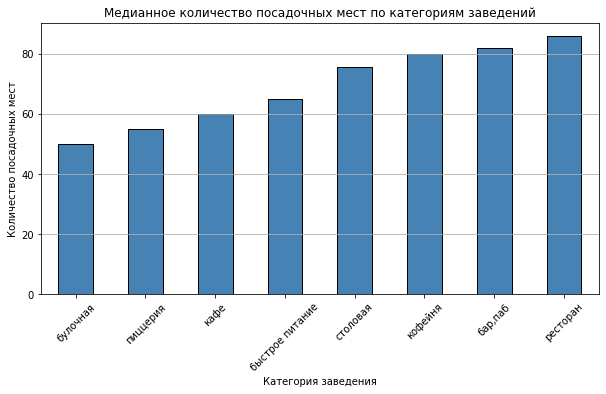

In [40]:
# Строим столбчатую диаграмму медианного количества мест по категориям
plt.figure(figsize=(10, 5))

seats_by_category.sort_values().plot(
    kind='bar',
    rot=45,
    color='steelblue',
    edgecolor='black',
    legend=False
)

plt.title('Медианное количество посадочных мест по категориям заведений')
plt.xlabel('Категория заведения')
plt.ylabel('Количество посадочных мест')
plt.grid(axis='y')
plt.show()

Распределение количества посадочных мест имеет выраженную правостороннюю асимметрию. Данные о посадочных местах представлены для 4792 заведений. Среднее количество мест составляет 108, тогда как медиана равна 75. Среднее значение заметно выше медианного, что указывает на наличие крупных заведений, которые смещают распределение вправо.

Диаграмма размаха подтверждает наличие выбросов. Максимальное значение достигает 1288 посадочных мест. Такие значения могут соответствовать крупным ресторанам, банкетным залам, ресторанам при гостиницах или корпоративным столовым. Минимальное значение равно 0, что может указывать либо на ошибку в данных, либо на заведения без посадочных мест, например точки выдачи заказов навынос.

При этом половина заведений имеет не более 75 посадочных мест, а 75% заведений - не более 140 мест. Значит, большинство объектов рассчитано на относительно небольшое количество посетителей.

Для сравнения категорий использована медиана, поскольку она менее чувствительна к выбросам. Наибольшее типичное количество мест характерно для ресторанов - 86, баров и пабов - 82, а также кофеен - 80. Наименьшее типичное количество посадочных мест наблюдается у булочных - 50, что соответствует их компактному формату.

---

### Задача 5. Рейтинг заведений

Исследуем рейтинг заведений общественного питания Москвы: изучим его распределение и сравним средние рейтинги по категориям заведений.

In [41]:
# Изучаем статистические показатели столбца rating
df['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

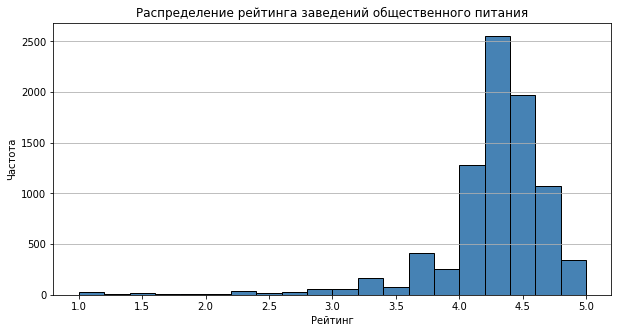

In [42]:
# Строим гистограмму распределения рейтинга заведений
plt.figure(figsize=(10, 5))

df['rating'].plot(
    kind='hist',
    bins=20,
    color='steelblue',
    edgecolor='black'
)

plt.title('Распределение рейтинга заведений общественного питания')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')
plt.grid(axis='y')
plt.show()

Теперь сравним средние рейтинги по категориям заведений.

In [43]:
# Рассчитываем средний рейтинг по каждой категории заведений
rating_by_category = df.groupby('category')['rating'].mean().sort_values(ascending=False).round(2)
rating_by_category

category
бар,паб            4.39
пиццерия           4.30
ресторан           4.29
кофейня            4.28
булочная           4.27
столовая           4.21
кафе               4.12
быстрое питание    4.05
Name: rating, dtype: float64

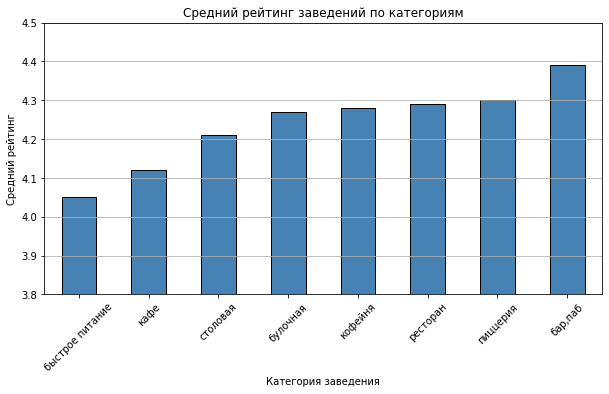

In [44]:
# Строим столбчатую диаграмму среднего рейтинга по категориям
plt.figure(figsize=(10, 5))

rating_by_category.sort_values().plot(
    kind='bar',
    rot=45,
    color='steelblue',
    edgecolor='black',
    legend=False
)

plt.title('Средний рейтинг заведений по категориям')
plt.xlabel('Категория заведения')
plt.ylabel('Средний рейтинг')
plt.ylim(3.8, 4.5)
plt.grid(axis='y')
plt.show()

Рейтинги заведений общественного питания Москвы в целом находятся на высоком уровне. Среднее значение составляет 4.23, медиана - 4.3, а 75% заведений имеют рейтинг не ниже 4.1. Это говорит о том, что большинство объектов оцениваются пользователями положительно.

Распределение рейтингов имеет левостороннюю асимметрию: основная часть значений сосредоточена в диапазоне от 4.0 до 4.5, а низкие оценки встречаются значительно реже.

В разрезе категорий различия выражены слабо. Наиболее высокий средний рейтинг наблюдается у баров и пабов - 4.39, далее идут пиццерии - 4.30 и рестораны - 4.29. Наименьший средний рейтинг у заведений быстрого питания - 4.05, однако и это значение остаётся достаточно высоким.

Таким образом, рейтинг не является сильным отличительным признаком между категориями: все форматы заведений в среднем оцениваются пользователями положительно.

---

### Задача 6. Корреляция рейтинга с другими данными

Изучим, с какими данными рейтинг заведений показывает наиболее сильную корреляцию. Построим матрицу корреляции рейтинга с категорией заведения, административным округом, статусом сетевого заведения, количеством посадочных мест, ценовой категорией и признаком круглосуточной работы. 
Для анализа используем коэффициент phi_k, который позволяет измерять связь между данными разной природы — числовыми и категориальными.

In [45]:
# Вычисляем матрицу корреляции phi_k для рейтинга и других признаков
correlation_matrix = df[['rating', 'category', 'district', 'chain',
                          'seats', 'price', 'is_24_7']].phik_matrix()

# Выводим корреляцию рейтинга с остальными признаками
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(
    by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.220295
district,0.200761
category,0.189716
is_24_7,0.150365
chain,0.107833
seats,0.000000


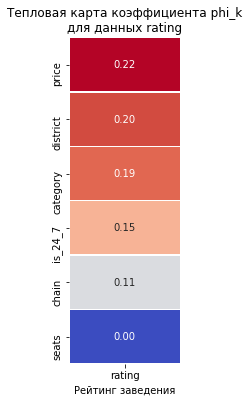

In [46]:
# Строим тепловую карту корреляции рейтинга с другими признаками
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

plt.figure(figsize=(2, 6))
sns.heatmap(data_heatmap,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False)

plt.title('Тепловая карта коэффициента phi_k\nдля данных rating')
plt.xlabel('Рейтинг заведения')
plt.show()

Анализ матрицы корреляции phi_k показал, что рейтинг заведения слабо связан со всеми рассмотренными признаками - ни один из коэффициентов не превышает значения 0.23. Это согласуется с предыдущим выводом о том, что рейтинги заведений в целом высокие и слабо различаются между категориями.

Наибольшую корреляцию рейтинг показывает с ценовой категорией (`price`) - 0.22, а также с административным округом (`district`) - 0.20 и категорией заведения (`category`) - 0.19. Признак круглосуточной работы (`is_24_7`) связан с рейтингом слабее - 0.15, а статус сетевого заведения (`chain`) - ещё слабее (0.11). Количество посадочных мест (`seats`) не показывает никакой связи с рейтингом - коэффициент равен 0.

Коэффициент `phi_k` показывает наличие связи между признаками, но не объясняет её направление и причину. Поэтому после построения матрицы отдельно проверим самый сильный найденный признак.
Наиболее сильную связь рейтинг демонстрирует с ценовой категорией заведения. Проверим эту зависимость подробнее.

In [47]:
# Рассчитываем средний рейтинг по ценовым категориям
rating_by_price = df.groupby('price')['rating'].mean().sort_values(ascending=False).round(2)
rating_by_price

price
высокие          4.44
выше среднего    4.39
средние          4.30
низкие           4.17
Name: rating, dtype: float64

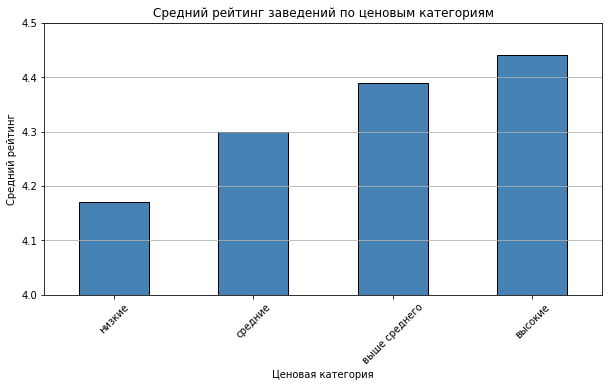

In [48]:
# Строим столбчатую диаграмму среднего рейтинга по ценовым категориям
plt.figure(figsize=(10, 5))

rating_by_price.sort_values().plot(
    kind='bar',
    rot=45,
    color='steelblue',
    edgecolor='black',
    legend=False
)

plt.title('Средний рейтинг заведений по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')
plt.ylim(4, 4.5)
plt.grid(axis='y')
plt.show()

Матрица корреляции `phi_k` показала, что рейтинг заведения слабо связан со всеми рассмотренными признаками. Ни один коэффициент не превышает 0.23, поэтому говорить о сильной зависимости рейтинга от отдельных характеристик нельзя.

Наибольшая связь наблюдается с ценовой категорией `price` - 0.22. Также слабая связь есть с административным округом - 0.20 и категорией заведения - 0.19. Признак круглосуточной работы связан с рейтингом ещё слабее - 0.15, статус сетевого заведения - 0.11, а количество посадочных мест не показывает связи с рейтингом.

Дополнительная проверка показала, что средний рейтинг действительно увеличивается вместе с ценовой категорией: у заведений с низкими ценами он составляет 4.17, со средними - 4.30, с ценами выше среднего - 4.39, а у заведений с высокими ценами - 4.44.

Таким образом, более дорогие заведения в среднем оцениваются выше, однако связь остаётся слабой. Вероятно, рейтинг зависит не от одного признака, а от совокупности факторов: качества сервиса, кухни, расположения, ожиданий аудитории и ценового сегмента.

---

### Задача 7. Топ-15 популярных сетей

Сгруппируем данные по названиям заведений и найдём топ-15 самых популярных сетей в Москве. Под популярностью понимается количество заведений сети в регионе. Для них рассчитаем средний рейтинг и определим, к каким категориям они относятся.

Для поиска сетей отберём только заведения с признаком `chain == 1` и сгруппируем их по названию. Поскольку названия мы ранее нормализовали (привели к нижнему регистру), одинаковые заведения сети будут корректно объединены в одну группу.

In [49]:
# Отбираем сетевые заведения и считаем количество заведений каждой сети
chain_networks = df[df['chain'] == 1]['name'].value_counts().head(15)
chain_networks

шоколадница                            120
домино'с пицца                          76
додо пицца                              74
one price coffee                        71
яндекс лавка                            69
cofix                                   65
prime                                   50
хинкальная                              44
кофепорт                                42
кулинарная лавка братьев караваевых     39
теремок                                 38
чайхана                                 37
cofefest                                32
буханка                                 32
му-му                                   27
Name: name, dtype: int64

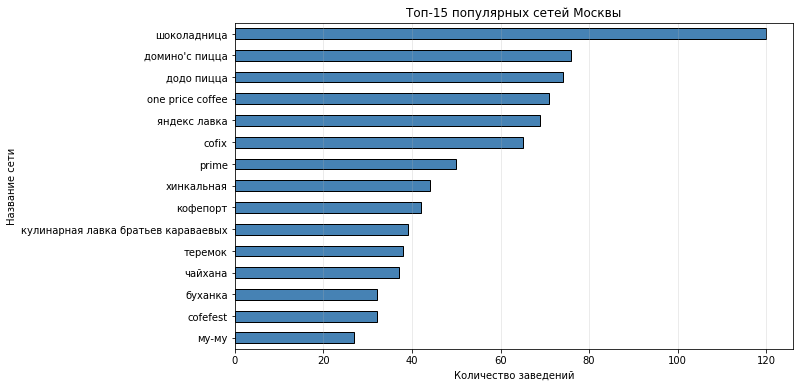

In [50]:
# Строим график топ-15 популярных сетей Москвы
plt.figure(figsize=(10, 6))

chain_networks.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)

plt.title('Топ-15 популярных сетей Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')
plt.grid(axis='x', alpha=0.3)
plt.show()

Получили топ-15 сетей по количеству заведений. Теперь для этих сетей рассчитаем средний рейтинг. Отберём данные только по этим сетям и сгруппируем их по названию.

In [51]:
# Получаем список названий топ-15 сетей
top_15_names = chain_networks.index

# Отбираем данные только по топ-15 сетям
top_15 = df[df['name'].isin(top_15_names)]

# Рассчитываем средний рейтинг для каждой сети
top_15_rating = top_15.groupby('name').agg({'rating': 'mean'}).sort_values(by='rating', ascending=False).round(2)
top_15_rating

,rating
name,
буханка,4.40
кулинарная лавка братьев караваевых,4.39
хинкальная,4.32
додо пицца,4.29
му-му,4.23
шоколадница,4.18
домино'с пицца,4.17
кофепорт,4.15
теремок,4.12


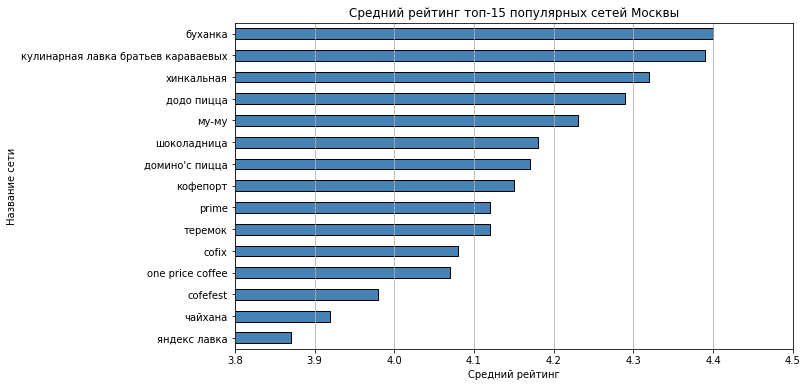

In [52]:
# Строим график среднего рейтинга топ-15 популярных сетей
plt.figure(figsize=(10, 6))

top_15_rating['rating'].sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)

plt.title('Средний рейтинг топ-15 популярных сетей Москвы')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.xlim(3.8, 4.5)
plt.grid(axis='x')
plt.show()

Теперь посмотрим, к каким категориям относятся эти сети.

In [53]:
# Определяем категорию каждой сети
top_15.groupby('name')['category'].unique()

name
cofefest                                                                 [кофейня, кафе]
cofix                                                                          [кофейня]
one price coffee                                                               [кофейня]
prime                                                                   [ресторан, кафе]
буханка                                                        [булочная, кофейня, кафе]
додо пицца                                                                    [пиццерия]
домино'с пицца                                                                [пиццерия]
кофепорт                                                                       [кофейня]
кулинарная лавка братьев караваевых                                               [кафе]
му-му                                  [кафе, ресторан, кофейня, быстрое питание, пиц...
теремок                                                      [ресторан, быстрое питание]
хинкальная      

Анализ популярных сетей показал, что крупнейшей сетью в Москве является «Шоколадница» - 120 заведений. Это заметно больше, чем у остальных сетей из топ-15, что делает её наиболее распространённым сетевым брендом в данных.

В топ популярных сетей входят преимущественно кофейни, кафе, пиццерии и заведения быстрого питания. Это подтверждает предыдущий вывод о том, что именно стандартизируемые форматы легче развиваются в сетевом формате.

При этом количество заведений не связано напрямую со средним рейтингом сети. Крупная сеть может иметь более умеренный рейтинг, тогда как менее представленная сеть может оцениваться выше. Это показывает, что масштаб сети отражает распространённость бренда, но не гарантирует более высокую пользовательскую оценку.

---

### Задача 8. Средний чек в зависимости от района

Изучим, как различается средний чек заведений общественного питания в зависимости от административного округа Москвы. Для этого сначала рассмотрим средние значения по округам, а затем дополнительно проанализируем медианные значения, поскольку средний чек может существенно искажаться из-за дорогих заведений.

In [54]:
# Рассчитываем средний чек по административным округам
avg_bill_by_district = df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False).round(0)
avg_bill_by_district

district
Центральный административный округ         1191.0
Западный административный округ            1053.0
Северный административный округ             928.0
Южный административный округ                834.0
Северо-Западный административный округ      822.0
Восточный административный округ            821.0
Юго-Западный административный округ         793.0
Северо-Восточный административный округ     717.0
Юго-Восточный административный округ        654.0
Name: middle_avg_bill, dtype: float64

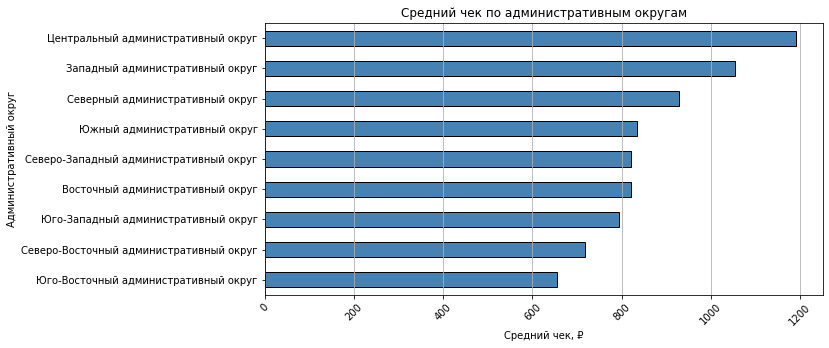

In [55]:
# Строим график среднего чека по административным округам
plt.figure(figsize=(10, 5))

avg_bill_by_district.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)

plt.title('Средний чек по административным округам')
plt.xlabel('Средний чек, ₽')
plt.ylabel('Административный округ')
plt.xticks(rotation=45)
plt.grid(axis='x')
plt.show()

По средним значениям видно, что наиболее высокий средний чек наблюдается в Центральном административном округе. Это можно объяснить высокой концентрацией туристических объектов, деловых центров и ресторанов более высокого ценового сегмента.

В остальных округах средний чек заметно ниже, что свидетельствует о более доступном уровне цен. Однако среднее значение может быть завышено из-за небольшого количества дорогих заведений, поэтому дополнительно рассмотрим медианный средний чек.

In [56]:
# Рассчитываем медианный средний чек по административным округам
bill_by_district = df.groupby('district')['middle_avg_bill'].median().sort_values(ascending=False).round(0)
bill_by_district

district
Западный административный округ            1000.0
Центральный административный округ         1000.0
Северо-Западный административный округ      700.0
Северный административный округ             650.0
Юго-Западный административный округ         600.0
Восточный административный округ            575.0
Северо-Восточный административный округ     500.0
Южный административный округ                500.0
Юго-Восточный административный округ        450.0
Name: middle_avg_bill, dtype: float64

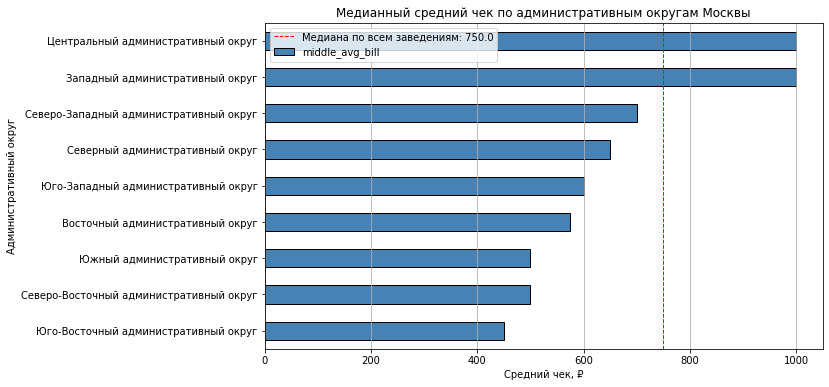

In [57]:
# Строим горизонтальную столбчатую диаграмму медианного чека по округам
plt.figure(figsize=(10, 6))

bill_by_district.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black',
    legend=False
)

# Наносим линию медианного чека по всем заведениям
median_bill = df['middle_avg_bill'].median()
plt.axvline(median_bill,
            color='red',
            linestyle='--',
            linewidth=1,
            label=f'Медиана по всем заведениям: {round(median_bill, 0)}')

plt.title('Медианный средний чек по административным округам Москвы')
plt.xlabel('Средний чек, ₽')
plt.ylabel('Административный округ')
plt.legend()
plt.grid(axis='x')
plt.show()

Анализ медианного среднего чека показал заметную вариацию цен в зависимости от расположения заведения. Самый высокий медианный чек зафиксирован в Западном и Центральном административных округах - по 1000 ₽. Это значительно выше, чем в остальных округах.

Далее следуют Северо-Западный округ - 700 ₽, Северный - 650 ₽, Юго-Западный - 600 ₽ и Восточный - 575 ₽. Наиболее низкие медианные чеки наблюдаются в Северо-Восточном и Южном округах - по 500 ₽, а минимальное значение зафиксировано в Юго-Восточном административном округе - 450 ₽.

Разница между средними и медианными значениями показывает, что в отдельных округах есть заведения с очень высоким средним чеком, которые могут завышать среднее значение. Поэтому медиана лучше отражает типичный уровень цен.

В целом прослеживается закономерность: цены выше в центральных и западных районах Москвы и ниже в более удалённых округах. Это может быть связано с более высокими арендными ставками, деловым и туристическим трафиком, а также большей платёжеспособностью аудитории.

Таким образом, расположение действительно связано с уровнем цен: заведения в центральных и западных округах в среднем дороже, тогда как в восточных и южных округах медианный чек заметно ниже.

---


### Промежуточный вывод

Исследовательский анализ позволил сформировать общее представление о рынке заведений общественного питания Москвы.

- Рынок сконцентрирован вокруг трёх основных форматов: кафе, ресторанов и кофеен. Вместе они составляют почти 70% всех заведений. Это говорит о высокой конкуренции в массовых категориях, но также подтверждает устойчивый спрос на такие форматы.

- По территории заведения распределены неравномерно. Центральный административный округ занимает лидирующее положение: на него приходится около 27% всех объектов. В остальных округах концентрация заведений заметно ниже, а минимальная доля наблюдается в Северо-Западном округе - менее 5%.

- По типу заведений рынок остаётся преимущественно несетевым: несетевые объекты составляют 62%, сетевые - 38%. При этом сетевой формат лучше всего развит у булочных, пиццерий и кофеен, то есть у форматов, которые легче стандартизировать и масштабировать.

- Большинство заведений имеет относительно небольшое количество посадочных мест: медиана составляет 75 мест. Крупные заведения встречаются реже и формируют выбросы в распределении. Наиболее вместительными категориями являются рестораны, бары и пабы, а наиболее компактными - булочные.

- Рейтинги заведений в целом высокие и слабо различаются между категориями. Средний рейтинг составляет 4.23, а самая заметная, хотя и слабая, связь рейтинга наблюдается с ценовой категорией: более дорогие заведения в среднем оцениваются выше.

- Цены также зависят от расположения. Самые высокие медианные чеки наблюдаются в Центральном и Западном административных округах - около 1000 ₽. В более удалённых округах, особенно в южном и юго-восточном направлении, типичный чек ниже - около 450–500 ₽.

## 4. Итоговый вывод и рекомендации

Полученные результаты позволяют сделать вывод, что наиболее перспективными для открытия нового заведения являются категории, сочетающие высокий спрос и умеренный уровень конкуренции. При выборе локации также необходимо учитывать различия между административными округами по концентрации заведений и уровню цен. Проведённый анализ может служить основой для принятия дальнейших инвестиционных решений.

### Общий обзор проделанной работы

В ходе исследования был проанализирован рынок заведений общественного питания Москвы на основе данных сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года. Исходные данные были представлены двумя датасетами - с информацией о заведениях и о ценах, которые были объединены в единый датафрейм по идентификатору заведения.

На этапе предобработки были скорректированы пропущенные значения, удалены неявные дубликаты (4 записи), нормализованы текстовые столбцы и создан дополнительный признак круглосуточной работы `is_24_7`. Итоговый датафрейм включил 8402 заведения.

Исследовательский анализ охватил категории заведений, их распределение по административным округам, соотношение сетевых и несетевых форматов, количество посадочных мест, рейтинги, корреляцию рейтинга с другими признаками, популярные сети и вариацию среднего чека по районам.

### Ответы на исследовательские вопросы

**Категории заведений.** Рынок представлен 8 категориями. Преобладают кафе (28%), рестораны (24%) и кофейни (17%), которые в сумме составляют почти 70% всех заведений.

**Расположение.** Заведения распределены по округам крайне неравномерно. Центральный административный округ значительно опережает остальные - здесь сосредоточено около 27% всех заведений. Наименее насыщен Северо-Западный округ (менее 5%).

**Сетевые и несетевые заведения.** Несетевые заведения преобладают (62% против 38%). Чаще всего сетевыми являются булочные (61%), пиццерии (52%) и кофейни (51%) - форматы, удобные для масштабирования.

**Посадочные места.** Половина заведений рассчитана не более чем на 75 мест. Больше всего мест у ресторанов (медиана 86) и баров (82), меньше всего - у булочных (50). В данных присутствуют выбросы - заведения с очень большим числом мест (до 1288), вероятно, банкетные залы и столовые.

**Рейтинги.** Рейтинги заведений в целом высокие (средний 4.23) и слабо различаются между категориями. Наиболее высоко оцениваются бары и пабы (4.39), ниже всего - заведения быстрого питания (4.05).

**Корреляция рейтинга.** Рейтинг слабо связан со всеми рассмотренными признаками. Наиболее сильная связь - с ценовой категорией: заведения более высокого ценового сегмента имеют более высокие оценки.

**Популярные сети.** Самая популярная сеть - «Шоколадница» (120 заведений). В топ-15 преобладают кофейни и пиццерии. Популярность сети не связана напрямую с её рейтингом.

**Средний чек по районам.** Цены выше в центральных и западных округах (около 1000 ₽) и снижаются к восточным и южным окраинам (450-500 ₽). Удалённость от центра напрямую влияет на стоимость заказа.

### Рекомендации

На основе проведённого анализа можно дать инвесторам следующие рекомендации:

1. **Категория заведения.** Наиболее перспективными форматами для входа на рынок выглядят кофейни и кафе - они пользуются стабильным спросом и хорошо масштабируются. Если инвесторы рассматривают сетевую модель, стоит обратить внимание на формат кофейни или пиццерии, поскольку именно в этих категориях сетевой формат наиболее распространён и проверен рынком.

2. **Расположение.** Центральный административный округ обеспечивает максимальный трафик, однако характеризуется высокой конкуренцией и высокими арендными ставками. Для нового заведения можно рассмотреть округа с хорошим балансом спроса и более низкой насыщенностью - например, Северный, Западный или Юго-Западный округа.

3. **Ценовая политика.** Поскольку более высокий ценовой сегмент связан с более высокими рейтингами, заведению стоит сделать акцент на качестве сервиса и продукта. При размещении в центральных или западных районах можно ориентироваться на средний чек около 1000₽, в более удалённых районах - на более доступные цены.

4. **Формат и вместимость.** Для кафе или кофейни оптимальным будет заведение на 60-80 посадочных мест - это типичный размер для данных форматов. Не стоит ориентироваться на крупные залы без чёткого понимания целевого трафика.

5. **Дополнительные возможности.** Можно рассмотреть круглосуточный режим работы как конкурентное преимущество - таких заведений на рынке менее 9%, что создаёт нишу, особенно в районах с высоким ночным трафиком.

Для более точного выбора места рекомендуется провести дополнительный анализ конкретных районов с учётом пешеходного трафика, стоимости аренды и платёжеспособности населения.